In [1]:
import sys, os
print(os.getcwd())
print(sys.path[0])

c:\Users\trakw\_workspace\micrograd-from-scratch
C:\Users\trakw\miniforge3\python313.zip


In [32]:
%load_ext autoreload
%autoreload 2

from micrograd.engine import Value
from micrograd.topo import topo
from micrograd.viz import plot_graph

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


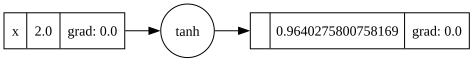

In [20]:
x = Value(2.0, "x")
y = x.tanh()
plot_graph(y)     # แก้ engine.py แล้วเซฟ รันเซลล์ใหม่ได้เลย ไม่ต้อง restart

In [21]:
y._backward()

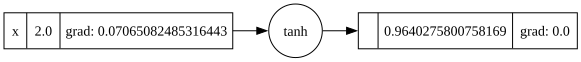

In [22]:
plot_graph(y)

In [14]:
y = Value(0.0).tanh()
print(y._backward)
# → <function Value.__init__.<locals>.<lambda> at 0x...>

a = Value(1.0) * Value(2.0)
print(a._backward)
# → <function Value.__mul__.<locals>._backward at 0x...>


<function __autoreload_class__.tanh.<locals>._backward at 0x00000206E5BBA8E0>
<function Value.__mul__.<locals>._backward at 0x00000206E5BBACA0>


In [17]:
print(y._backward.__qualname__)
print(y._backward.__code__.co_freevars)

__autoreload_class__.tanh.<locals>._backward
('self', 't')


In [25]:
l = [1,2,3]
print(l)
print(*l)

[1, 2, 3]
1 2 3


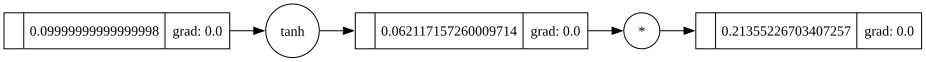

In [33]:
x = Value(0.5)
y = x.tanh()
z = y * y
plot_graph(z)

In [28]:
z.backward()

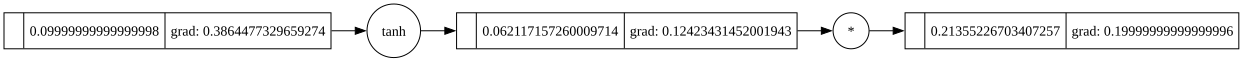

In [30]:
plot_graph(z)

# Python

## Decorator

```
@foo
def bar():
    ...
```

=

```
def bar():
    ...
bar = foo(bar)
```

### Ex1

In [39]:
def printfooafter(f):
    def g():
        f()
        print("foo")
    return g

In [42]:
def bar():
    print("bar")

bar()

bar


In [43]:
@printfooafter
def bar():
    print("bar")
     
bar()

bar
foo


### Ex2

In [46]:
def greet():
    return "hi"
    
f = greet
f()

'hi'

In [47]:
def shout(fn):
    def wrapper():
        return fn().upper() + "!"
    return wrapper

loud = shout(greet)
loud()

'HI!'

In [48]:
@shout
def greet():
    return "hi"

greet()

'HI!'

### Ex3

In [49]:
def cases(*values):
    def attach(fn):
        fn.cases = values
        return fn
    return attach

@cases(1, 2, 3)
def double(x):
    return x*2

double(5)

10

In [65]:
double.cases

(1, 2, 3)

In [64]:
cases

<function __main__.cases(*values)>

In [63]:
pytest.mark.parametrize

MarkDecorator(mark=Mark(name='parametrize', args=(), kwargs={}))

In [50]:
for c in double.cases:
    print(f"double[{c}] -> {double(c)}")

double[1] -> 2
double[2] -> 4
double[3] -> 6


### Ex4

In [51]:
import pytest

CASES = [
    pytest.param(2, 3, 5, id="2+3"),
    pytest.param(10, 1, 11, id="10+1"),
]

@pytest.mark.parametrize("a, b, expected", CASES)
def test_adds(a, b, expected):
    assert a + b == expected


In [52]:
@pytest.mark.parametrize('x', [1, 2, 3])
def demo(x):
    return x

In [62]:
demo(5)
print(demo.pytestmark)

[Mark(name='parametrize', args=('x', [1, 2, 3]), kwargs={})]


In [60]:
sorted(demo.__dict__)

['pytestmark']

In [58]:
def plain(): pass
plain.anything_i_want = {'a': 1}     # ใส่อะไรก็ได้
plain.anything_i_want

{'a': 1}

In [61]:
sorted(plain.__dict__)

['anything_i_want']

### Ex5

In [67]:
a = [1,2,3]
*a

SyntaxError: can't use starred expression here (1087030344.py, line 2)

In [ ]:
import pytest

CASES = [
    pytest.param(2, 3, 5, id="2+3"),
    pytest.param(10, 1, 11, id="10+1"),
]

@pytest.mark.parametrize("a, b, expected", CASES)
def test_adds(a, b, expected):
    assert a + b == expected


In [83]:
def myparametrize(myvar, mycase):
    def attach(fn):
        fn.myvar = myvar
        fn.mycase = mycase
        return fn
    return attach

mycase = [
    (1, 2, 3),
    (4, 5, 9)
]

@myparametrize("a, b, c", mycase)
def mytest(a, b, c):
    # print(f"a = {a}")
    # print(f"b = {b}")
    # print(f"c = {c}")
    assert a + b == c
    print(f"{a}+{b}={c}")
    
myvarliststring = [p.strip() for p in mytest.myvar.split(",")]

for c in mytest.mycase:
    mytest(*c)

1+2=3
4+5=9
